In [14]:
from scipy.io import arff
import pandas as pd

# 1. Încarcă fișierul .arff
data, meta = arff.loadarff('php0iVrYT.arff') # Înlocuiește cu numele real

# 2. Transformă-l într-un DataFrame Pandas
df = pd.DataFrame(data)

# 3. IMPORTANT: În fișierele ARFF, string-urile sunt adesea salvate ca 'bytes' (ex: b'da')
# Codul de mai jos le transformă în text normal pentru a putea lucra cu ele
for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode('utf-8')

# Verificăm dacă a mers
print("Datele au fost încărcate cu succes!")
print(df.head())

Datele au fost încărcate cu succes!
    V1    V2       V3    V4 Class
0  2.0  50.0  12500.0  98.0     2
1  0.0  13.0   3250.0  28.0     2
2  1.0  16.0   4000.0  35.0     2
3  2.0  20.0   5000.0  45.0     2
4  1.0  24.0   6000.0  77.0     1


In [15]:
import pandas as pd
from scipy.io import arff

# Încărcare date
data, meta = arff.loadarff('php0iVrYT.arff')
df = pd.DataFrame(data)

# Decodare format bytes (pentru text curat)
for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode('utf-8')

# --- ÎNCEPUT EDA ---
print("Structura setului de date:")
df.info()

print("\nVerificare valori lipsă (Missing Values):")
print(df.isnull().sum())

print("\nStatistici descriptive:")
display(df.describe())

Structura setului de date:
<class 'pandas.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      748 non-null    float64
 1   V2      748 non-null    float64
 2   V3      748 non-null    float64
 3   V4      748 non-null    float64
 4   Class   748 non-null    str    
dtypes: float64(4), str(1)
memory usage: 29.3 KB

Verificare valori lipsă (Missing Values):
V1       0
V2       0
V3       0
V4       0
Class    0
dtype: int64

Statistici descriptive:


,V1,V2,V3,V4
count,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086
std,8.095396,5.839307,1459.826781,24.376714
min,0.000000,1.000000,250.000000,2.000000
25%,2.750000,2.000000,500.000000,16.000000
50%,7.000000,4.000000,1000.000000,28.000000
75%,14.000000,7.000000,1750.000000,50.000000
max,74.000000,50.000000,12500.000000,98.000000


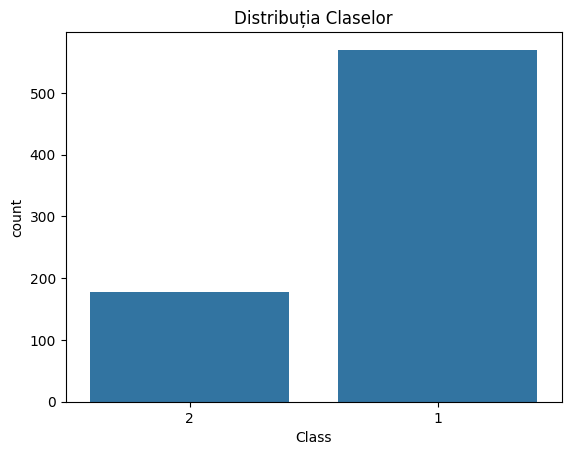

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Verificăm dacă avem clase echilibrate
sns.countplot(x='Class', data=df)
plt.title('Distribuția Claselor')
plt.show()

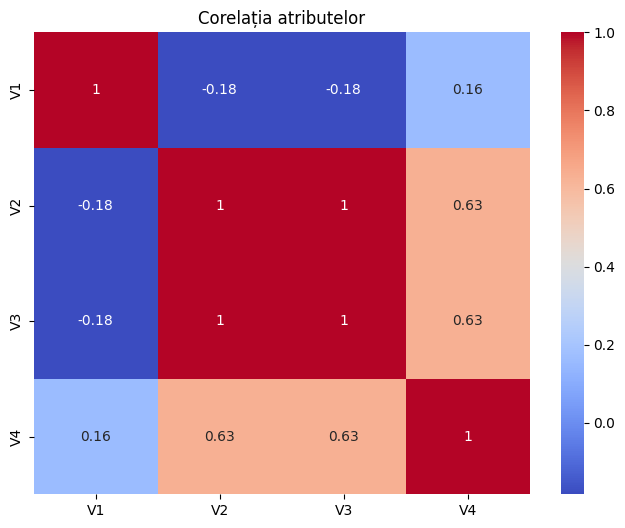

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Corelația atributelor')
plt.show()

Scorurile de importanță pentru fiecare caracteristică:
V4    0.432471
V1    0.274809
V2    0.151254
V3    0.141466
dtype: float64


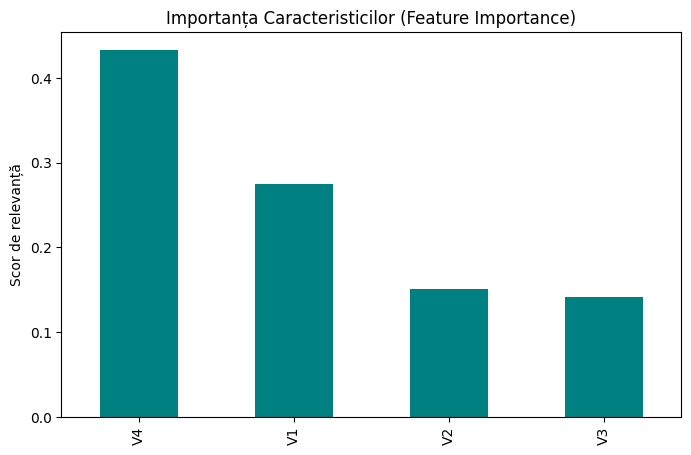

In [18]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# 1. Pregătim datele: X sunt caracteristicile, y este ținta (Class)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Antrenăm un model rapid pentru a vedea importanța
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# 3. Extragem și afișăm importanța fiecărei coloane
importante = pd.Series(model.feature_importances_, index=X.columns)
importante = importante.sort_values(ascending=False)

print("Scorurile de importanță pentru fiecare caracteristică:")
print(importante)

# Vizualizare grafică
plt.figure(figsize=(8,5))
importante.plot(kind='bar', color='teal')
plt.title('Importanța Caracteristicilor (Feature Importance)')
plt.ylabel('Scor de relevanță')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split date: 80% antrenare, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scalarea datelor (obligatorie pentru Logistic Regression și SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datele au fost împărțite și scalate cu succes.")

Datele au fost împărțite și scalate cu succes.


In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Definirea modelelor și a grilei de parametri
model_params = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100], 'max_depth': [None, 10]}
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
    },
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {'C': [0.1, 1, 10]}
    }
}

# Procesul de GridSearch
comparatie_modele = []
for nume_model, mp in model_params.items():
    print(f"Se antrenează {nume_model}...")
    grid = GridSearchCV(mp['model'], mp['params'], cv=5)
    grid.fit(X_train_scaled, y_train)
    comparatie_modele.append({
        'Model': nume_model,
        'Best_Score (Acuratețe)': grid.best_score_,
        'Best_Params': grid.best_params_
    })

# Afișarea rezultatelor brute (Tabel comparativ)
df_comparatie = pd.DataFrame(comparatie_modele)
display(df_comparatie)

Se antrenează RandomForest...
Se antrenează SVM...
Se antrenează LogisticRegression...


,Model,Best_Score (Acuratețe),Best_Params
0,RandomForest,0.772577,"{'max_depth': 10, 'n_estimators': 100}"
1,SVM,0.780938,"{'C': 1, 'kernel': 'rbf'}"
2,LogisticRegression,0.777633,{'C': 1}



--- RAPORT FINAL DE CLASIFICARE ---
              precision    recall  f1-score   support

           1       0.77      0.97      0.86       113
           2       0.57      0.11      0.18        37

    accuracy                           0.76       150
   macro avg       0.67      0.54      0.52       150
weighted avg       0.72      0.76      0.69       150



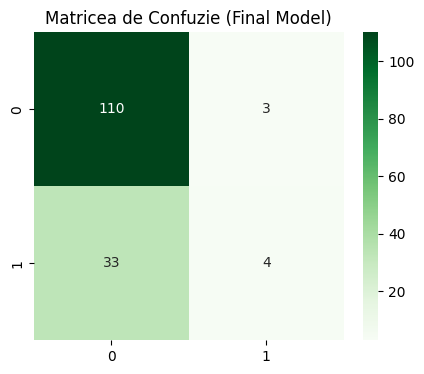

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluăm ultimul model antrenat (LogisticRegression în cazul tău din loop)
# sau poți re-evalua modelul SVM care a ieșit cel mai bun (0.78)
y_pred = grid.best_estimator_.predict(X_test_scaled)

print("\n--- RAPORT FINAL DE CLASIFICARE ---")
print(classification_report(y_test, y_pred))

# Opțional: Matricea de confuzie pentru a vedea erorile vizual
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Matricea de Confuzie (Final Model)')
plt.show()